In [ ]:
from pydub import AudioSegment, silence
import os

audio = AudioSegment.from_file("", format="mp3") 

min_silence_len = 700  
silence_thresh = audio.dBFS - 14

# Split on silence
chunks = silence.split_on_silence(
    audio,
    min_silence_len=min_silence_len,
    silence_thresh=silence_thresh,
    keep_silence=300  # optional: retain some silence at the split point
)

# Save or process each chunk
os.makedirs("smart_cut_out", exist_ok=True)

for i, chunk in enumerate(chunks):
    out_file = f"smart_cut_out/smart_cut_audio_{i+1}.wav"
    chunk.export(out_file, format="wav")
    print(f"Saved: {out_file}")



Saved: smart_cut_out/smart_cut_audio_1.wav
Saved: smart_cut_out/smart_cut_audio_2.wav
Saved: smart_cut_out/smart_cut_audio_3.wav
Saved: smart_cut_out/smart_cut_audio_4.wav
Saved: smart_cut_out/smart_cut_audio_5.wav
Saved: smart_cut_out/smart_cut_audio_6.wav
Saved: smart_cut_out/smart_cut_audio_7.wav
Saved: smart_cut_out/smart_cut_audio_8.wav
Saved: smart_cut_out/smart_cut_audio_9.wav
Saved: smart_cut_out/smart_cut_audio_10.wav
Saved: smart_cut_out/smart_cut_audio_11.wav
Saved: smart_cut_out/smart_cut_audio_12.wav
Saved: smart_cut_out/smart_cut_audio_13.wav
Saved: smart_cut_out/smart_cut_audio_14.wav
Saved: smart_cut_out/smart_cut_audio_15.wav
Saved: smart_cut_out/smart_cut_audio_16.wav
Saved: smart_cut_out/smart_cut_audio_17.wav
Saved: smart_cut_out/smart_cut_audio_18.wav
Saved: smart_cut_out/smart_cut_audio_19.wav
Saved: smart_cut_out/smart_cut_audio_20.wav
Saved: smart_cut_out/smart_cut_audio_21.wav
Saved: smart_cut_out/smart_cut_audio_22.wav
Saved: smart_cut_out/smart_cut_audio_23.w

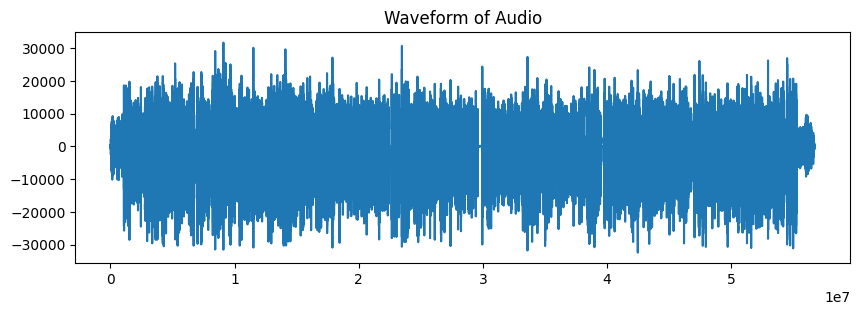

In [6]:
import matplotlib.pyplot as plt
import numpy as np

samples = np.array(audio.get_array_of_samples())
plt.figure(figsize=(10, 3))
plt.plot(samples)
plt.title("Waveform of Audio")
plt.show()

In [2]:
from pydub import AudioSegment, silence
import os
import json

# Load the audio
audio = AudioSegment.from_file("/home/znyd/hacking/edu-cut/src/pre_processing/downloads/audio/vector_3B1B.mp3", format="mp3")

# Parameters
min_silence_len = 700  # ms
silence_thresh = audio.dBFS - 14  # Adaptive threshold
keep_silence = 300  # optional: retain silence padding

# Split and keep track of time
chunks = []
start_times = []
current_time = 0

# Get silent ranges to compute start/end accurately
silent_ranges = silence.detect_silence(
    audio, min_silence_len=min_silence_len, silence_thresh=silence_thresh
)

# Flatten the cut points
cut_points = [0] + [r[1] for r in silent_ranges] + [len(audio)]

# Remove very short segments (optional)
cut_points = sorted(set(cut_points))
cut_pairs = [(cut_points[i], cut_points[i+1]) for i in range(len(cut_points)-1)]

# Prepare output folder
os.makedirs("smart_cut_out", exist_ok=True)

# Metadata list
metadata = []

# Process chunks
for i, (start, end) in enumerate(cut_pairs):
    # Adjust for silence padding if needed
    start_adj = max(0, start - keep_silence // 2)
    end_adj = min(len(audio), end + keep_silence // 2)

    chunk = audio[start_adj:end_adj]
    filename = f"smart_cut_out/sentence_{i+1}.wav"
    chunk.export(filename, format="wav")

    # Append to metadata
    metadata.append({
        "chunk_index": i + 1,
        "filename": filename,
        "start_time_ms": start_adj//1000,
        "end_time_ms": end_adj//1000,
        "duration_ms": (end_adj - start_adj)//1000
    })

# Write metadata to JSON
with open("smart_cut_out/segments_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Processed {len(metadata)} segments. Metadata saved to segments_metadata.json")


✅ Processed 73 segments. Metadata saved to segments_metadata.json
